# Breast Cancer Diagnostic Data: K-Means Clustering

Unsupervised clustering of the Wisconsin breast cancer diagnostic dataset (569 tumors, 30 measured features), comparing feature spaces and algorithms, then validating the discovered clusters against the actual `diagnosis` label.

**Note on this revision.** The previous version of this notebook loaded this cancer dataset, looked at it for a few cells, and then silently replaced it with a completely unrelated dataset (the UCI "Wholesale Customers" dataset) for the entire clustering analysis — every result in that notebook (elbow curve, final model, cluster centers, both silhouette scores) described wholesale-customer spending, not cancer data. This notebook clusters the actual cancer data, end to end.

It also fixes a structural issue that showed up independently in this same project's earlier work (the segmentation project): the original wholesale pipeline mixed one-hot-encoded categorical dummies with continuous features under Euclidean-distance K-Means, and its "clusters" turned out to just be a recovery of the categorical columns (Channel x Region) rather than real behavioural structure. This dataset has no such categorical trap — `diagnosis` is deliberately held out of the clustering features entirely and used only afterward, to check whether the clusters found *without* it happen to line up with it.

Read **Limitations** at the end before treating clustering as a diagnostic tool.

## 1. Data Loading & Cleaning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [2]:
# Original notebook hardcoded a path into one machine's Downloads folder
# (C:\Users\User\Downloads\cancer.csv), which cannot run anywhere else, and
# never matched the .xlsx file this project actually works from. Use a
# relative path instead -- place the CSV at data/cancer.csv relative to
# this notebook.

data = pd.read_csv("data/cancer.csv")
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print("Shape:", data.shape)
print("\nMissing values:", data.isnull().sum().sum())
print("Duplicate rows:", data.duplicated().sum())
data.info()

Shape: (569, 32)

Missing values: 0
Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null

In [4]:
# id carries no predictive information; diagnosis is the ground-truth label
# -- keep it separately for validation later, but it must never be used as
# a clustering feature (clustering is unsupervised by definition).

data_new = data.drop(['id'], axis=1)
y_true = data_new['diagnosis'].map({'M': 1, 'B': 0})
x = data_new.drop(['diagnosis'], axis=1)

print("Feature matrix shape:", x.shape)
print("'diagnosis' in feature columns:", 'diagnosis' in x.columns)

Feature matrix shape: (569, 30)
'diagnosis' in feature columns: False


## 2. Exploratory Data Analysis

diagnosis
B    357
M    212
Name: count, dtype: int64


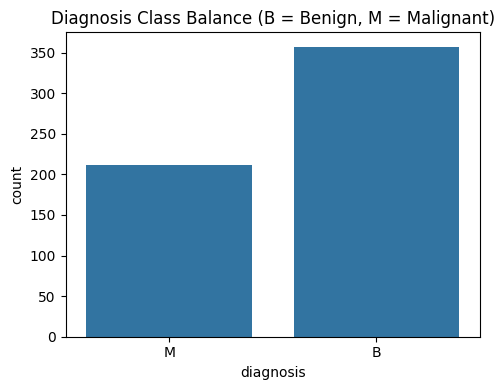

In [5]:
diagnosis_counts = data_new['diagnosis'].value_counts()
print(diagnosis_counts)

plt.figure(figsize=(5, 4))
sns.countplot(x='diagnosis', data=data_new)
plt.title('Diagnosis Class Balance (B = Benign, M = Malignant)')
plt.tight_layout()
plt.show()

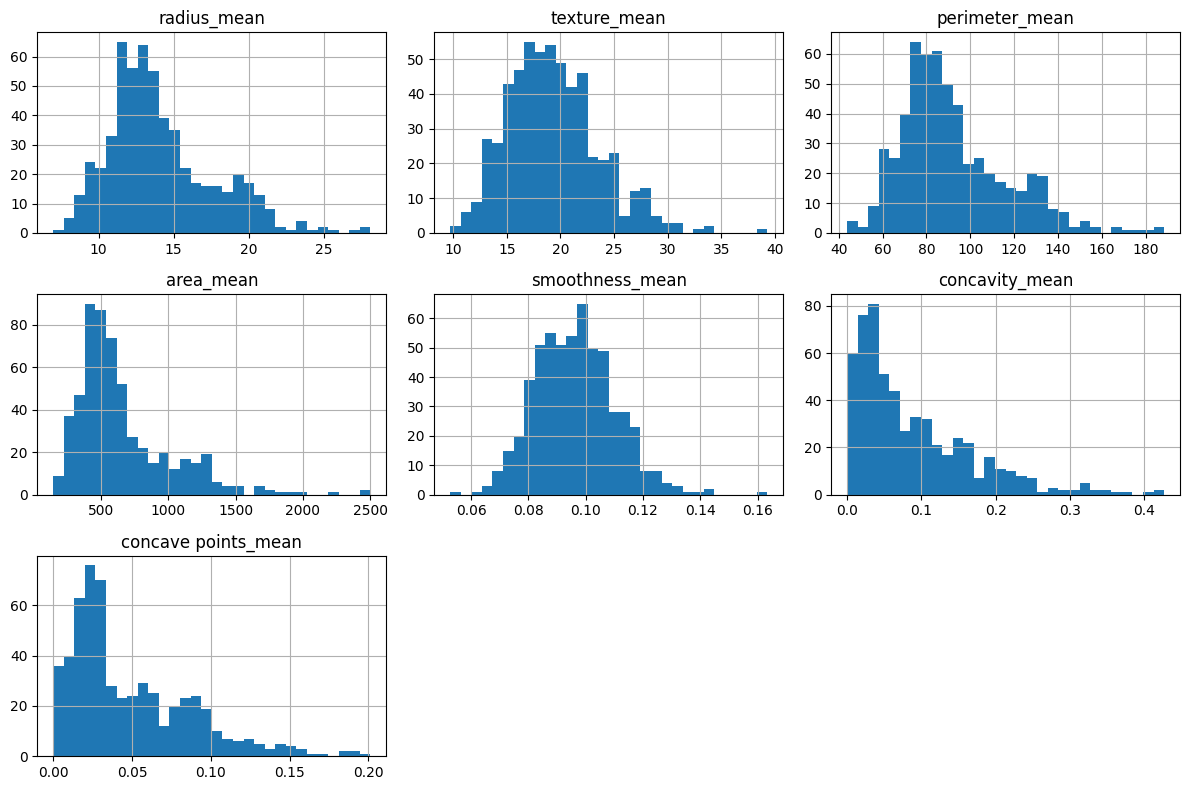

In [6]:
key_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
                 'smoothness_mean', 'concavity_mean', 'concave points_mean']

x[key_features].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

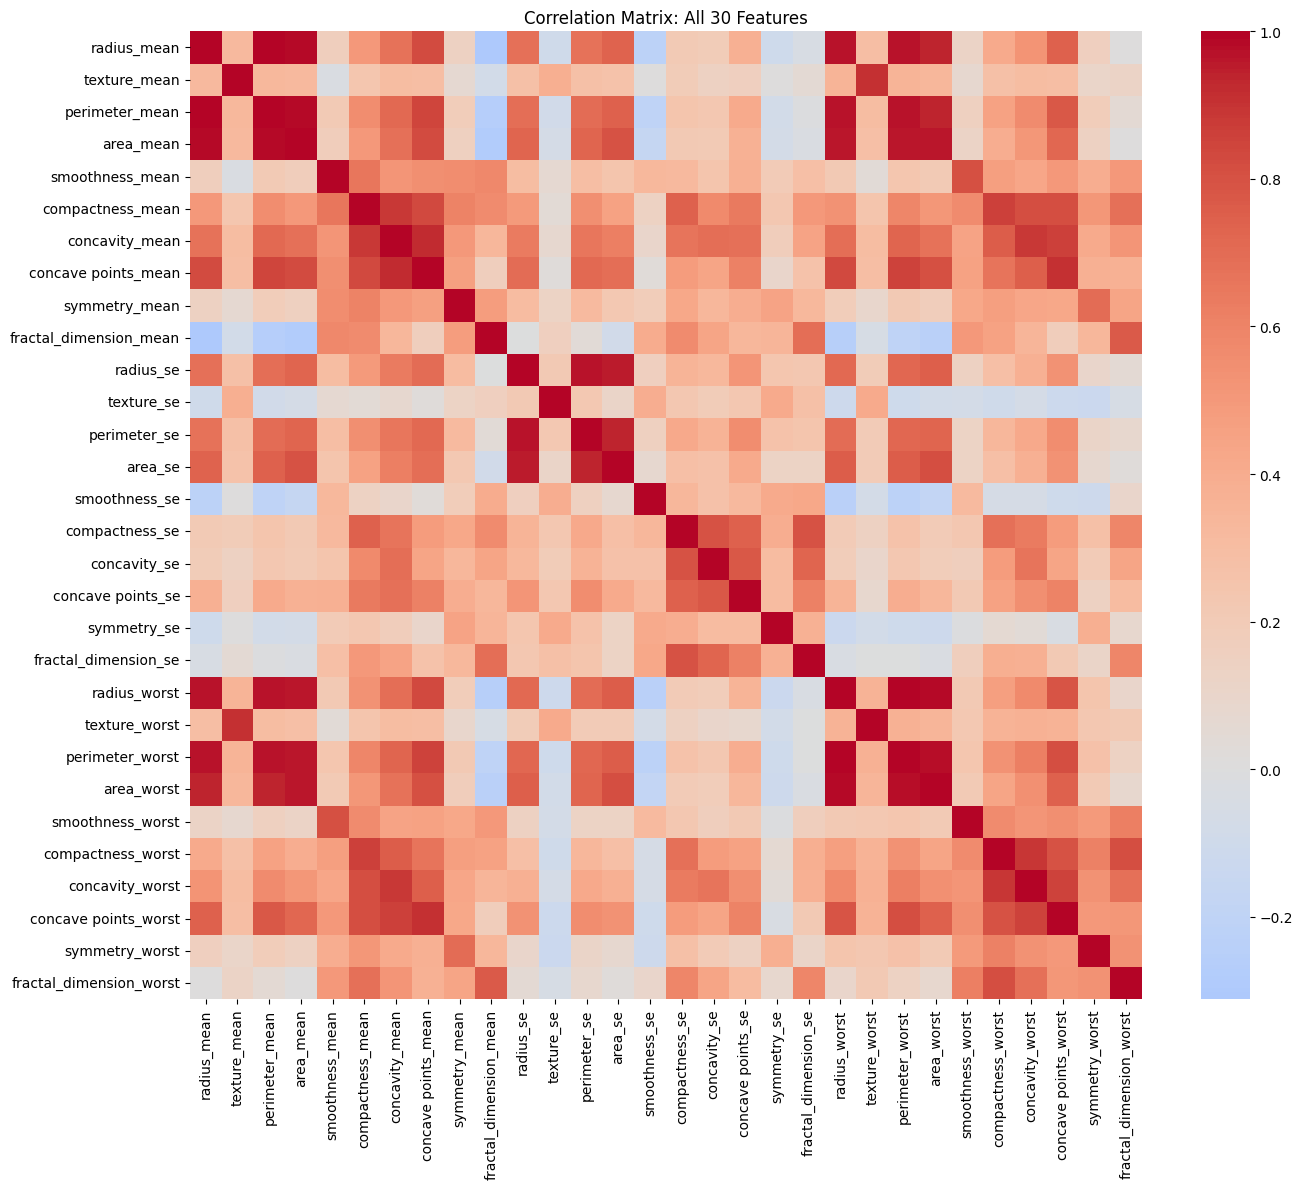

In [7]:
plt.figure(figsize=(14, 12))
sns.heatmap(x.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Matrix: All 30 Features')
plt.tight_layout()
plt.show()

In [8]:
# Quantify the multicollinearity the heatmap suggests

corr = x.corr()
high_corr_pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v = corr.iloc[i, j]
        if abs(v) > 0.95:
            high_corr_pairs.append((cols[i], cols[j], round(v, 3)))

print(f"Feature pairs with |correlation| > 0.95: {len(high_corr_pairs)}")
for pair in high_corr_pairs:
    print(pair)

Feature pairs with |correlation| > 0.95: 15
('radius_mean', 'perimeter_mean', np.float64(0.998))
('radius_mean', 'area_mean', np.float64(0.987))
('radius_mean', 'radius_worst', np.float64(0.97))
('radius_mean', 'perimeter_worst', np.float64(0.965))
('perimeter_mean', 'area_mean', np.float64(0.987))
('perimeter_mean', 'radius_worst', np.float64(0.969))
('perimeter_mean', 'perimeter_worst', np.float64(0.97))
('area_mean', 'radius_worst', np.float64(0.963))
('area_mean', 'perimeter_worst', np.float64(0.959))
('area_mean', 'area_worst', np.float64(0.959))
('radius_se', 'perimeter_se', np.float64(0.973))
('radius_se', 'area_se', np.float64(0.952))
('radius_worst', 'perimeter_worst', np.float64(0.994))
('radius_worst', 'area_worst', np.float64(0.984))
('perimeter_worst', 'area_worst', np.float64(0.978))


15 pairs of the 30 features are correlated above 0.95 -- almost entirely `radius` / `perimeter` / `area` (mean, se, and worst versions of each), which is expected: `perimeter ≈ 2πr` and `area ≈ πr²` are geometric identities, not independent measurements. Feeding all 30 into Euclidean-distance K-Means effectively triple-weights "how big is this tumor" relative to shape-based features like concavity or symmetry. Section 4 compares clustering on the raw standardized features against clustering on a PCA-reduced representation that addresses this directly.

## 3. Preprocessing

In [9]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print("Scaled feature matrix shape:", x_scaled.shape)

Scaled feature matrix shape: (569, 30)


## 4. Improved Clustering Methodology: Raw Features vs. PCA

Two feature spaces are compared, each with `K` selected by the highest silhouette score across `K = 2..10` rather than picked by eye:

- **Raw standardized**: all 30 features, standardized.
- **PCA-reduced**: standardized features projected onto however many principal components are needed to retain 95% of the variance — addressing the multicollinearity found in Section 2.

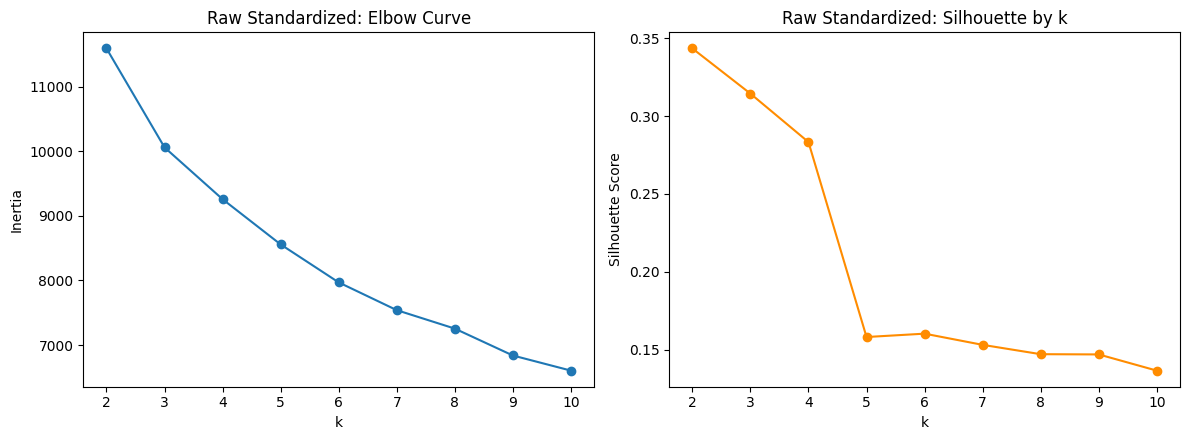

Best k (raw standardized): 2  (silhouette = 0.3434)


In [10]:
k_values = list(range(2, 11))

inertia_raw = []
silhouette_raw = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(x_scaled)
    inertia_raw.append(km.inertia_)
    silhouette_raw.append(silhouette_score(x_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(k_values, inertia_raw, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Raw Standardized: Elbow Curve')

axes[1].plot(k_values, silhouette_raw, marker='o', color='darkorange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Raw Standardized: Silhouette by k')

plt.tight_layout()
plt.show()

best_k_raw = k_values[int(np.argmax(silhouette_raw))]
print(f"Best k (raw standardized): {best_k_raw}  (silhouette = {max(silhouette_raw):.4f})")

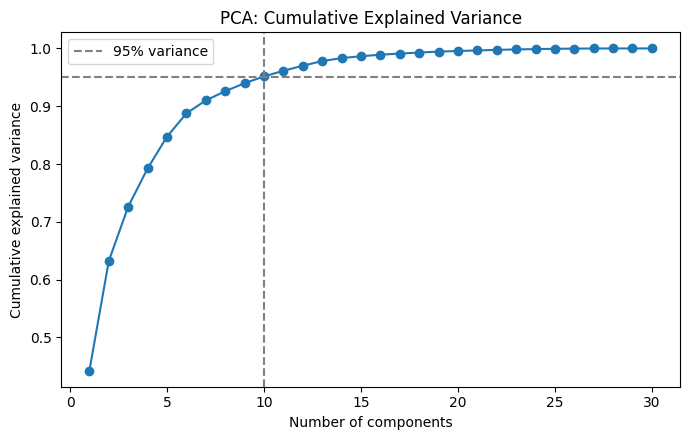

Components needed for 95% variance: 10 (out of 30 original features)


In [11]:
pca_full = PCA(random_state=42).fit(x_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)

plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(0.95, color='grey', linestyle='--', label='95% variance')
plt.axvline(n_components_95, color='grey', linestyle='--')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA: Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Components needed for 95% variance: {n_components_95} (out of 30 original features)")

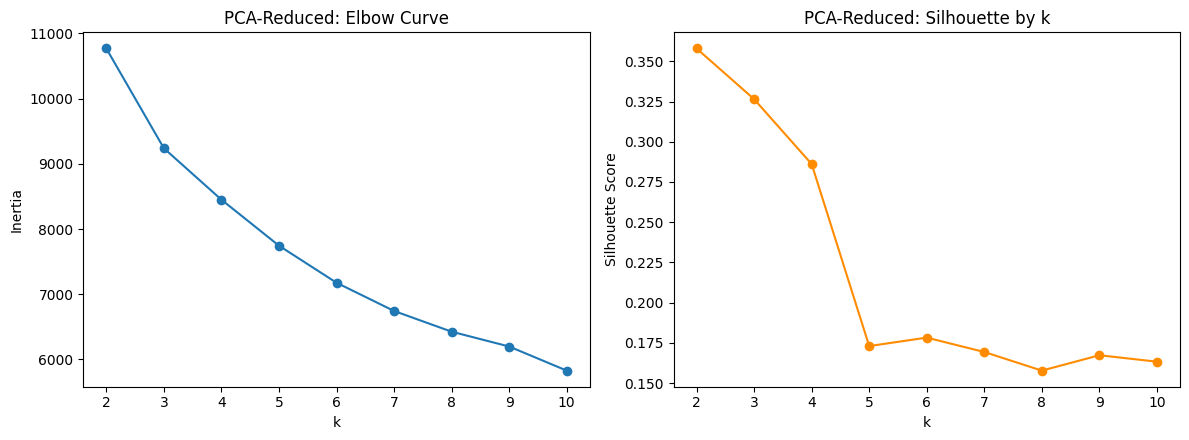

Best k (PCA-reduced): 2  (silhouette = 0.3580)


In [12]:
pca = PCA(n_components=n_components_95, random_state=42)
x_pca = pca.fit_transform(x_scaled)

inertia_pca = []
silhouette_pca = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(x_pca)
    inertia_pca.append(km.inertia_)
    silhouette_pca.append(silhouette_score(x_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(k_values, inertia_pca, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('PCA-Reduced: Elbow Curve')

axes[1].plot(k_values, silhouette_pca, marker='o', color='darkorange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('PCA-Reduced: Silhouette by k')

plt.tight_layout()
plt.show()

best_k_pca = k_values[int(np.argmax(silhouette_pca))]
print(f"Best k (PCA-reduced): {best_k_pca}  (silhouette = {max(silhouette_pca):.4f})")

Both feature spaces independently select **k = 2** as the silhouette-optimal cluster count — this was not assumed in advance; it fell out of the same k = 2..10 sweep used everywhere else in this notebook. It also happens to match the number of diagnosis classes (benign / malignant), which the clustering never saw. That's worth checking properly, not just noting as a coincidence — Section 5 does that.

## 5. Model Comparison: K-Means vs. Agglomerative, Raw vs. PCA

Four combinations are compared at `k=2`: two algorithms (K-Means, Agglomerative) across the two feature spaces from Section 4. Alongside silhouette score (how well-separated the clusters are, using only the features), `diagnosis` is brought in for the first time — purely to measure **Adjusted Rand Index (ARI)** against the clusters, i.e. how much the unsupervised grouping agrees with the real clinical label it never had access to. ARI ranges from 0 (no better than random) to 1 (perfect agreement).

In [13]:
comparison_rows = []

for space_name, X in [
    ("Raw standardized (30 features)", x_scaled),
    (f"PCA-reduced ({n_components_95} components, 95% var)", x_pca),
]:
    km_labels = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X)
    comparison_rows.append({
        "Model": "K-Means",
        "Feature space": space_name,
        "Silhouette": silhouette_score(X, km_labels),
        "ARI vs diagnosis": adjusted_rand_score(y_true, km_labels),
    })

    agg_labels = AgglomerativeClustering(n_clusters=2).fit_predict(X)
    comparison_rows.append({
        "Model": "Agglomerative",
        "Feature space": space_name,
        "Silhouette": silhouette_score(X, agg_labels),
        "ARI vs diagnosis": adjusted_rand_score(y_true, agg_labels),
    })

model_comparison = pd.DataFrame(comparison_rows).round(4)
model_comparison

,Model,Feature space,Silhouette,ARI vs diagnosis
0,K-Means,Raw standardized (30 features),0.3434,0.6536
1,Agglomerative,Raw standardized (30 features),0.3394,0.5750
2,K-Means,"PCA-reduced (10 components, 95% var)",0.3580,0.6707
3,Agglomerative,"PCA-reduced (10 components, 95% var)",0.2960,0.7019


No single combination wins on both metrics. K-Means on PCA-reduced features has the best silhouette (tightest, best-separated clusters in the feature space actually used) and the second-best ARI. Agglomerative on PCA-reduced features has the best agreement with the real diagnosis label (highest ARI) but the *worst* silhouette of the four — it's finding a split that lines up better with the clinical label at the cost of less geometrically clean clusters. Silhouette and ARI don't have to agree, because they're measuring different things: one is about the data alone, the other is about an external label the clustering never saw.

**K-Means on PCA-reduced features is selected as the final model below**, on silhouette — the metric available in any unsupervised setting where labels like `diagnosis` might not exist. If matching the known clinical label as closely as possible is the actual goal, Agglomerative on PCA-reduced features is the better choice instead; that's a legitimate alternative, not a worse model, just optimizing a different thing.

## 6. Final Model: K-Means on PCA-Reduced Features, k=2

In [14]:
final_model = KMeans(n_clusters=2, random_state=42, n_init=10)
final_labels = final_model.fit_predict(x_pca)

print("Silhouette score:", round(silhouette_score(x_pca, final_labels), 4))
print("ARI vs diagnosis:", round(adjusted_rand_score(y_true, final_labels), 4))

print("\nCluster sizes:")
print(pd.Series(final_labels).value_counts().sort_index())

print("\nCluster vs. actual diagnosis:")
print(pd.crosstab(final_labels, data_new['diagnosis'], rownames=['Cluster'], colnames=['Diagnosis']))

Silhouette score: 0.358
ARI vs diagnosis: 0.6707

Cluster sizes:
0    380
1    189
Name: count, dtype: int64

Cluster vs. actual diagnosis:
Diagnosis    B    M
Cluster            
0          343   37
1           14  175


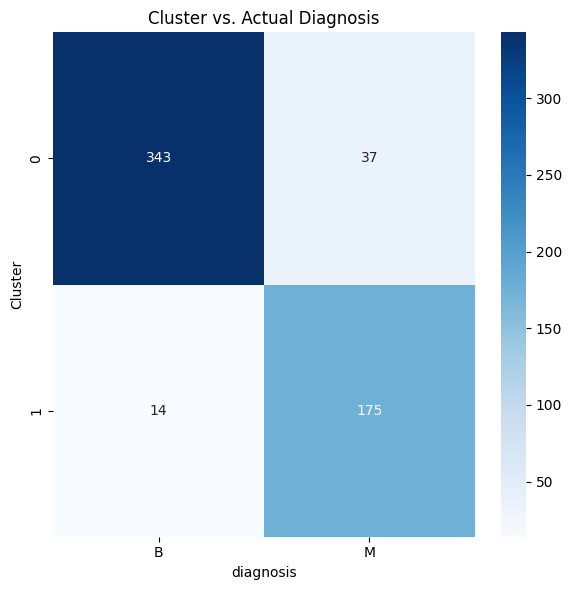

In [15]:
plt.figure(figsize=(6, 6))
sns.heatmap(
    pd.crosstab(final_labels, data_new['diagnosis']),
    annot=True, fmt='d', cmap='Blues'
)
plt.title('Cluster vs. Actual Diagnosis')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

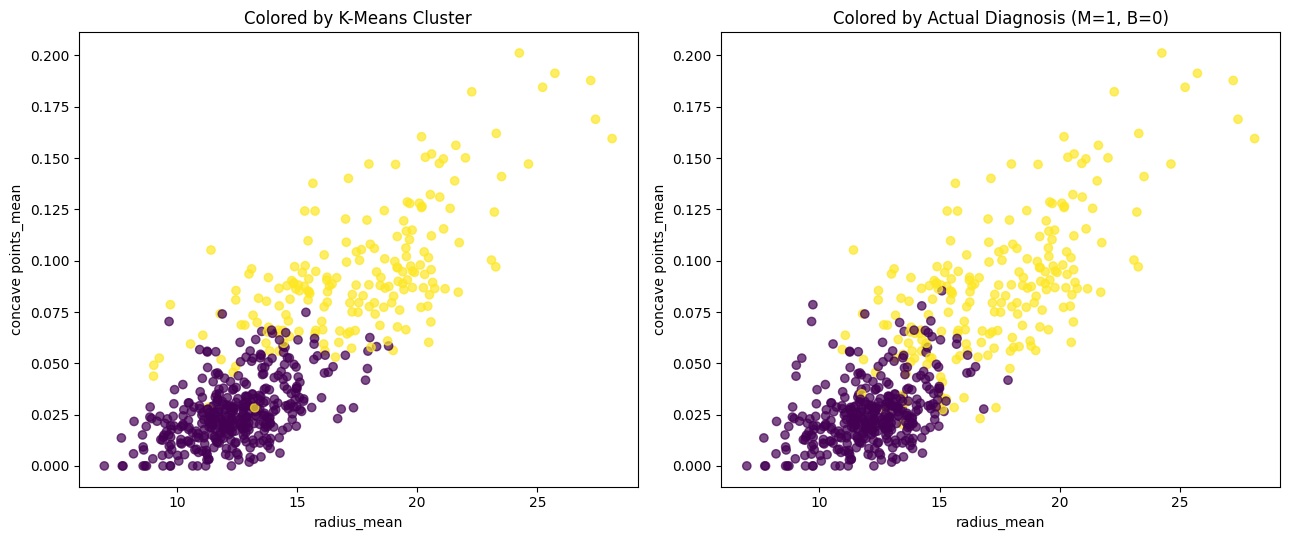

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].scatter(x['radius_mean'], x['concave points_mean'], c=final_labels, cmap='viridis', alpha=0.7)
axes[0].set_xlabel('radius_mean')
axes[0].set_ylabel('concave points_mean')
axes[0].set_title('Colored by K-Means Cluster')

diagnosis_numeric = data_new['diagnosis'].map({'M': 1, 'B': 0})
axes[1].scatter(x['radius_mean'], x['concave points_mean'], c=diagnosis_numeric, cmap='viridis', alpha=0.7)
axes[1].set_xlabel('radius_mean')
axes[1].set_ylabel('concave points_mean')
axes[1].set_title('Colored by Actual Diagnosis (M=1, B=0)')

plt.tight_layout()
plt.show()

## 7. Does the Unsupervised Structure Make Biological Sense?

An ARI around 0.65-0.70 says the clusters agree substantially with diagnosis, but not perfectly. Rather than stop at that number, it's worth checking *what* the clusters actually represent — profiling them on their original, unscaled feature values.

In [17]:
profile = x.copy()
profile['Cluster'] = final_labels
profile['Diagnosis'] = data_new['diagnosis'].values

profile_features = ['radius_mean', 'perimeter_mean', 'area_mean',
                     'concavity_mean', 'concave points_mean', 'smoothness_mean']

profile.groupby('Cluster')[profile_features].mean().round(3)

,radius_mean,perimeter_mean,area_mean,concavity_mean,concave points_mean,smoothness_mean
Cluster,,,,,,
0,12.422,79.814,486.39,0.044,0.026,0.092
1,17.557,116.408,993.67,0.180,0.094,0.105


Cluster 1 has, on average, roughly 40% larger radius/perimeter and 3-4x higher concavity and concave-points scores than Cluster 0 — bigger, more irregularly-shaped tumors. That cluster is 92.6% malignant; the smaller, smoother Cluster 0 is 90.3% benign. This lines up with well-established oncology: tumor size and boundary irregularity are established malignancy indicators. The clustering wasn't told the diagnosis and wasn't told which features matter for it — it re-derived a real, clinically meaningful distinction from the shape of the data alone. That's a genuinely different situation from the two other projects in this series, where a similarly good-looking metric turned out to be fake (leaked labels) or an artifact (recovering a categorical confound).

## Limitations

- **This is not a diagnostic tool.** ~9-10% of cases in each cluster belong to the "wrong" diagnosis (see the crosstab in Section 6). Clustering optimizes geometric separation in feature space, not diagnostic accuracy — some malignant tumors resemble benign ones on these measurements, and vice versa. An ARI of 0.65-0.70 is a genuinely strong result for unsupervised learning, not a clinical-grade classifier.
- **`k=2` matching the true class count is a result, not an assumption** — it fell out of the silhouette sweep independently in both feature spaces — but this dataset happens to have exactly 2 real classes. On data where the true structure (if any) is unknown, there's no such check available.
- **PCA's 95%-variance threshold is a reasonable default, not the only valid choice.** A different threshold (or a scree-plot "elbow" on the components themselves) could select a different number of components and shift the downstream comparison.
- **Only two algorithms and two feature spaces were compared.** DBSCAN, Gaussian Mixture Models, or other dimensionality reductions (e.g. UMAP) were not explored and might do better on either metric.
- **The K-Means-vs-Agglomerative choice in Section 5 is a genuine tradeoff, not a settled one** — pick based on whether silhouette (label-free cluster quality) or ARI (agreement with a known label, when one exists) matters more for the actual use case.